In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")

Libraries imported successfully!


In [24]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("(0 = malignant, 1 = benign)")

Dataset shape: (569, 30)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64
(0 = malignant, 1 = benign)


In [25]:
print("\nMissing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())
print("Negative values:", (X < 0).sum().sum())
print("All three checks came back clean — verified programmatically, not assumed.")



Missing values: 0
Duplicate rows: 0
Negative values: 0
All three checks came back clean — verified programmatically, not assumed.


In [27]:
correlation_matrix = X.corr()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if corr > 0.95:
            high_corr_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], corr)
            )

print(f"\nFeature pairs with correlation > 0.95: {len(high_corr_pairs)}")
for a, b, c in high_corr_pairs[:5]:
    print(f"  {a} <-> {b}: {c:.3f}")


Feature pairs with correlation > 0.95: 15
  mean radius <-> mean perimeter: 0.998
  mean radius <-> mean area: 0.987
  mean radius <-> worst radius: 0.970
  mean radius <-> worst perimeter: 0.965
  mean perimeter <-> mean area: 0.987


In [28]:
cols_to_drop = sorted({b for _, b, _ in high_corr_pairs})
print(f"\nDropping {len(cols_to_drop)} redundant columns for the linear model:")
print(cols_to_drop)

X_reduced = X.drop(columns=cols_to_drop)
print(f"Reduced feature set: {X.shape[1]} -> {X_reduced.shape[1]} columns")


Dropping 7 redundant columns for the linear model:
['area error', 'mean area', 'mean perimeter', 'perimeter error', 'worst area', 'worst perimeter', 'worst radius']
Reduced feature set: 30 -> 23 columns


In [29]:
X["mean_compactness_ratio"] = (X["mean perimeter"] ** 2) / X["mean area"]
X_reduced["mean_compactness_ratio"] = X["mean_compactness_ratio"]
print("\nEngineered feature 'mean_compactness_ratio' added "
      "(perimeter^2 / area — higher = more irregular shape).")


Engineered feature 'mean_compactness_ratio' added (perimeter^2 / area — higher = more irregular shape).


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train_full, X_test_full = X.loc[X_train.index], X.loc[X_test.index]

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 455, Test size: 114
Train class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

baseline_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)
baseline_pred = baseline_model.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("\nBaseline Results (always predicts majority class)")
print("Accuracy :", round(baseline_accuracy, 3))
print("Precision:", round(baseline_precision, 3))
print("Recall   :", round(baseline_recall, 3))
print("F1 Score :", round(baseline_f1, 3))


Baseline Results (always predicts majority class)
Accuracy : 0.632
Precision: 0.632
Recall   : 1.0
F1 Score : 0.774


In [32]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_train_scaled, y_train)
logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)
logistic_roc_auc = roc_auc_score(y_test, logistic_prob)

print("\nLogistic Regression Results")
print("Accuracy :", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall   :", round(logistic_recall, 3))
print("F1 Score :", round(logistic_f1, 3))
print("ROC-AUC  :", round(logistic_roc_auc, 3))


Logistic Regression Results
Accuracy : 0.974
Precision: 0.986
Recall   : 0.972
F1 Score : 0.979
ROC-AUC  : 0.993


In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
rf_model.fit(X_train_full, y_train)
rf_pred = rf_model.predict(X_test_full)
rf_prob = rf_model.predict_proba(X_test_full)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("\nRandom Forest Results")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1 Score :", round(rf_f1, 3))
print("ROC-AUC  :", round(rf_roc_auc, 3))


Random Forest Results
Accuracy : 0.956
Precision: 0.959
Recall   : 0.972
F1 Score : 0.966
ROC-AUC  : 0.992


In [34]:
results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [baseline_accuracy, logistic_accuracy, rf_accuracy],
    "Precision": [baseline_precision, logistic_precision, rf_precision],
    "Recall": [baseline_recall, logistic_recall, rf_recall],
    "F1 Score": [baseline_f1, logistic_f1, rf_f1],
    "ROC-AUC": [np.nan, logistic_roc_auc, rf_roc_auc],
}).set_index("Model")

print("\nModel Comparison:")
print(results.round(3))


Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Baseline                0.632      0.632   1.000     0.774      NaN
Logistic Regression     0.974      0.986   0.972     0.979    0.993
Random Forest           0.956      0.959   0.972     0.966    0.992


In [35]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=[0, 1])
malignant_correct   = cm_rf[0, 0]
malignant_missed     = cm_rf[0, 1]   # malignant predicted as benign — DANGEROUS
benign_false_alarm    = cm_rf[1, 0]  # benign predicted as malignant
benign_correct        = cm_rf[1, 1]

print("\nRandom Forest confusion matrix (rows=actual, cols=predicted):")
print(cm_rf)
print("\nCorrectly identified malignant   :", malignant_correct)
print("Malignant missed (predicted benign, the costly error):", malignant_missed)
print("Benign false alarm (predicted malignant):", benign_false_alarm)
print("Correctly identified benign      :", benign_correct)

if malignant_missed > 0:
    print(f"\n⚠ {malignant_missed} malignant case(s) were misclassified as benign.")
    print("This is the error type that matters most clinically — a missed")
    print("cancer diagnosis — even though overall accuracy looks high.")

print("\nClassification report — Random Forest:")
print(classification_report(y_test, rf_pred, target_names=["Malignant", "Benign"]))

print("Classification report — Logistic Regression:")
print(classification_report(y_test, logistic_pred, target_names=["Malignant", "Benign"]))


# 10. FEATURE IMPORTANCE (Random Forest)

importances = pd.Series(
    rf_model.feature_importances_, index=X_train_full.columns
).sort_values(ascending=False)
print("\nTop 5 most important features (Random Forest):")
print(importances.head(5))


Random Forest confusion matrix (rows=actual, cols=predicted):
[[39  3]
 [ 2 70]]

Correctly identified malignant   : 39
Malignant missed (predicted benign, the costly error): 3
Benign false alarm (predicted malignant): 2
Correctly identified benign      : 70

⚠ 3 malignant case(s) were misclassified as benign.
This is the error type that matters most clinically — a missed
cancer diagnosis — even though overall accuracy looks high.

Classification report — Random Forest:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification report — Logistic Regression:
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98

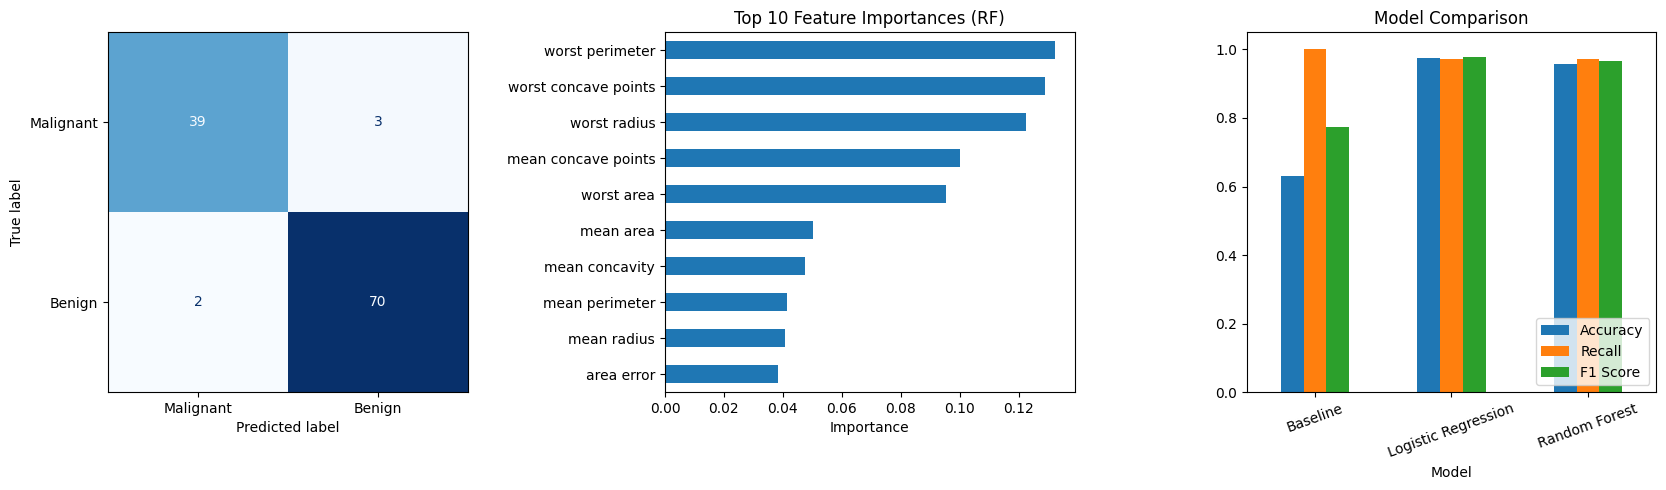

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Malignant", "Benign"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

importances.head(10).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 Feature Importances (RF)")
axes[1].set_xlabel("Importance")

comparison_plot = results[["Accuracy", "Recall", "F1 Score"]]
comparison_plot.plot(kind="bar", ax=axes[2])
axes[2].set_title("Model Comparison")
axes[2].set_ylim(0, 1.05)
axes[2].legend(loc="lower right")
axes[2].tick_params(axis='x', rotation=20)

tight_layout = plt.tight_layout()

plt.show()